<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2274529/1369044375.py:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[1].set_xlabel("Diameter ($\mu$m)")


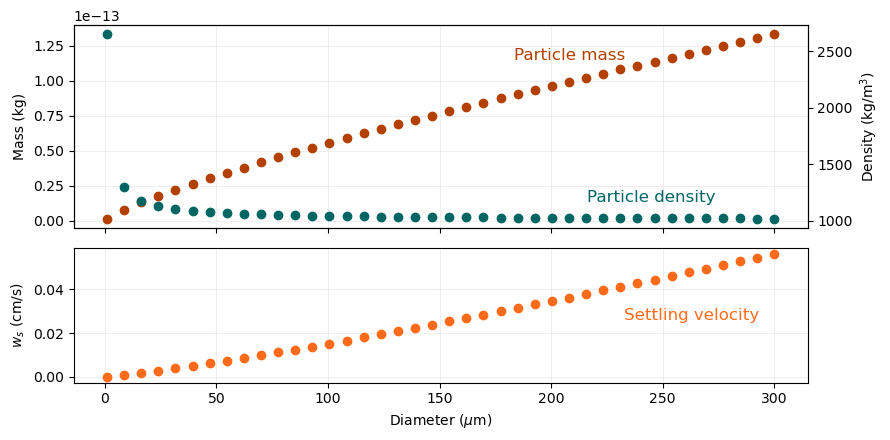

In [72]:
import numpy as np 
import matplotlib.pyplot as plt


rho_s = 2650
rho_w = 1000
N = 40                  # Number of sediment size classes
Dp = 1e-6 
nf = 2.2
nu = 1.5e-6
g = 9.81
D = np.linspace(1e-6, 300e-6, N) #.* 1e-6     # Sediment grain sizes (\mu m )

density = np.zeros(N)
mass = np.zeros(N)
ws = np.zeros(N)
for i in range(N):# floc_density[][i]
    mass[i] =  rho_s * np.pi/6 * D[i]**3 * (Dp/D[i])**nf 
    density[i] = rho_w + (rho_s - rho_w) * (D[i]/Dp)**(nf - 3)
    ws[i] = g/(18*nu) * (density[i] - rho_w)/(rho_w) * D[i]**2 

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(9,4.5), sharex=True, sharey=False, height_ratios=[1.5,1])
axs[0].plot(D*1e6, mass, 'o', color="#B33F00")
ax1 = axs[0].twinx()

ax1.plot(D*1e6, density, 'o', color="#006663")
axs[1].plot(D*1e6, ws*100, 'o', color="#FF6B1A")

axs[0].annotate("Particle density", xy=(0.7, 0.15), xycoords='axes fraction', ha='left', va='center', fontsize=12, color="#006663")
axs[0].annotate("Particle mass", xy=(0.6, 0.85), xycoords='axes fraction', ha='left', va='center', fontsize=12, color="#B33F00")
axs[1].annotate("Settling velocity", xy=(0.75, 0.5), xycoords='axes fraction', ha='left', va='center', fontsize=12, color="#FF6B1A")
axs[0].set_ylabel("Mass (kg)")
ax1.set_ylabel("Density (kg/m$^3$)")
axs[1].set_ylabel("$w_s$ (cm/s)")
axs[1].set_xlabel("Diameter ($\mu$m)")

plt.tight_layout()
for ax in axs:
    ax.grid(alpha=0.2)

fig.savefig("plots/floc_properties.png", dpi=300)